# 第 6 周 a｜Cox 回归：风险比、混杂与个体风险预测

> **本周怎么学**：先学这份精讲，再做 `w06b_cox_model.ipynb`（工程实践：项目用 statsmodels 实现的 Cox、只在训练集拟合、从 HR 到 5 年绝对风险）。
>
> 本篇的小节从 **5** 开始编号，接着第 5 周 a 的第 1–4 节。

**这一节学什么**
- 用 **Cox 比例风险模型**估计风险比（HR），画"左表右图"的森林图
- 理解**粗 HR 和调整 HR**的区别，以及"预测"和"因果"是两个不同的问题
- 检查比例风险假设、评估区分度（C 指数），并预测个体的 5 年风险

**用到的数据**：Data Asset 1 的全部 5 万人（5.9 节演示训练 / 测试划分）

**前置**：第 5 周（删失、KM 曲线）

In [1]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test, proportional_hazard_test
from lifelines.utils import concordance_index

from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "run.py").exists())  # 向上找项目根目录
sys.path.insert(0, str(ROOT))

from primecvd import paths                 # 数据与输出路径（primecvd/paths.py）
from primecvd import pubplot as pp         # 顶刊风格作图工具箱（值得通读：primecvd/pubplot.py）
pp.setup()


df = pd.read_csv(paths.ASSET1)
print(df.shape)

(50000, 12)


## 5. Cox 比例风险模型

### 5.1 风险比（HR）是什么？

Cox 模型估计每个变量的 **HR**：在任一时刻，暴露组的"瞬时发病风险"是对照组的多少倍。
- **HR = 1**：没有关联
- **HR > 1**：风险更高（比如 HR = 2 表示风险是 2 倍）
- **HR < 1**：风险更低（保护性）

### 5.2 先做一个单变量模型……并踩一个坑

先只放糖尿病一个变量。糖尿病组的发病率约 80.5/千人年，非糖尿病组约 3.6/千人年（见第 2 周 a），所以 HR 应该在 **20 左右**。

In [2]:
data_dm = df[["diabetes", "cvd_time", "cvd_event"]]

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    try:
        naive = CoxPHFitter().fit(data_dm, duration_col="cvd_time", event_col="cvd_event")
        print(f"默认设置得到的 HR = {naive.hazard_ratios_['diabetes']:.3f}")
    except Exception as e:
        print("默认设置拟合失败：", type(e).__name__)

默认设置得到的 HR = 0.000


😱 **HR ≈ 0？** 意思是糖尿病"几乎完全保护"不得心血管病，这显然是错的，而且**程序没有报错**！

**原因**：Cox 模型用牛顿法迭代求解。糖尿病的效应非常强，第一步迭代就"迈得太大"，越过了正确答案，之后越跑越远（数值发散）。lifelines 默认的初始步长比较激进；R 的 `survival::coxph` 在这种情况下会自动把步长减半，所以不会出问题。

**解决**：把初始步长调小，`fit_options={"step_size": 0.5}`。本项目后面所有 Cox 模型都这样设置，结果已经和 R `survival::coxph` 核对过，一致到小数点后第 3 位。

In [3]:
FIT_OPTIONS = {"step_size": 0.5}

cox_dm = CoxPHFitter().fit(data_dm, duration_col="cvd_time", event_col="cvd_event",
                           fit_options=FIT_OPTIONS)
cox_dm.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%,p
covariate,,,,
diabetes,22.18633,20.291747,24.257805,0.0


现在 HR ≈ 22，95% CI 约 20–24，和发病率之比（80.5 / 3.6 ≈ 22）吻合。

💡 **这一课比 Cox 模型本身更重要**：模型的输出一定要和描述性统计**交叉核对**。数字不合常识时，先怀疑代码和算法，而不是急着解释"新发现"。

### 5.3 准备多变量模型的数据

两个关键决定：

**① 连续变量用什么"单位"？** Cox 模型给出的是"变量每增加 1 个单位"的 HR。年龄每增加 1 岁的 HR 是 1.07，不直观；换成**每 10 岁**就清楚多了。选择有临床意义的单位：

| 变量 | 单位 |
|---|---|
| 年龄 | 每 10 岁 |
| BMI | 每 5 kg/m² |
| 收缩压 | 每 10 mmHg |
| eGFR | 每 10 mL/min/1.73m² |
| HbA1c | 每 1% |

**② 分类变量怎么编码？** 做成 0/1 的**哑变量（dummy variable）**，并选一个**参照组**。每个 HR 都是"和参照组相比"。
- 吸烟：参照组 = 从不吸烟
- IRSD：参照组 = 5（最富裕），这样 HR > 1 表示"比最富裕的人群风险更高"

In [4]:
def make_design(data):
    """把原始数据转换成 Cox 模型需要的变量（单位缩放 + 哑变量）"""
    X = pd.DataFrame(index=data.index)
    X["age_10"] = data["Age"] / 10
    X["bmi_5"] = data["BMI"] / 5
    X["sbp_10"] = data["SBP"] / 10
    X["egfr_10"] = data["eGFR"] / 10
    X["hba1c"] = data["HbA1c"]
    X["diabetes"] = data["diabetes"]
    X["CKD"] = data["CKD"]
    X["AF"] = data["AF"]
    X["smoke_ex"] = (data["smoking_status"] == "ex").astype(int)
    X["smoke_current"] = (data["smoking_status"] == "current").astype(int)
    for q in [1, 2, 3, 4]:                          # IRSD 5 是参照组，不放进模型
        X[f"irsd_{q}"] = (data["IRSD_quintile"] == q).astype(int)
    return X


# 给每个变量一个中文标签，用于展示结果
LABELS = {
    "age_10": "年龄（每 10 岁）", "bmi_5": "BMI（每 5 kg/m²）", "sbp_10": "收缩压（每 10 mmHg）",
    "egfr_10": "eGFR（每 10 单位）", "hba1c": "HbA1c（每 1%）", "diabetes": "糖尿病",
    "CKD": "慢性肾病", "AF": "房颤", "smoke_ex": "已戒烟 vs 从不", "smoke_current": "现在吸烟 vs 从不",
    "irsd_1": "IRSD 1 最贫困 vs 5", "irsd_2": "IRSD 2 vs 5", "irsd_3": "IRSD 3 vs 5", "irsd_4": "IRSD 4 vs 5",
}

X = make_design(df)
model_data = X.assign(cvd_time=df["cvd_time"], cvd_event=df["cvd_event"])
model_data.head()

,age_10,bmi_5,sbp_10,egfr_10,hba1c,diabetes,CKD,AF,smoke_ex,smoke_current,irsd_1,irsd_2,irsd_3,irsd_4,cvd_time,cvd_event
0,5.039527,5.633269,11.866819,8.307756,4.317890,0,0,0,0,0,0,0,0,1,2.963423,1
1,3.922676,3.365198,12.371973,8.148840,4.700951,0,0,0,1,0,0,0,1,0,4.407252,0
2,5.548900,4.704684,12.665052,8.677923,3.669685,0,0,0,0,0,0,0,0,0,4.490739,0
3,5.191053,6.396386,11.388967,9.470409,4.486977,0,0,0,0,0,0,0,0,1,4.888965,0
4,4.709157,5.070232,12.591262,8.633626,4.315440,0,0,0,1,0,1,0,0,0,4.490326,0


### 5.4 拟合多变量 Cox 模型

In [5]:
cph = CoxPHFitter().fit(model_data, duration_col="cvd_time", event_col="cvd_event",
                        fit_options=FIT_OPTIONS)


def hr_table(model):
    """整理成论文常见的格式：HR (95% CI) 和 P 值"""
    s = model.summary
    out = pd.DataFrame({
        "HR": s["exp(coef)"],
        "下限": s["exp(coef) lower 95%"],
        "上限": s["exp(coef) upper 95%"],
        "P": s["p"],
    })
    out["HR (95% CI)"] = out.apply(lambda r: f"{r.HR:.2f} ({r.下限:.2f}–{r.上限:.2f})", axis=1)
    out["P 值"] = out["P"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
    out.index = [LABELS.get(i, i) for i in out.index]
    return out


results = hr_table(cph)
paths.save_table(results[["HR (95% CI)", "P 值"]], "03_cox_multivariable")
results[["HR (95% CI)", "P 值"]]

,HR (95% CI),P 值
年龄（每 10 岁）,1.96 (1.88–2.04),<0.001
BMI（每 5 kg/m²）,1.11 (1.06–1.17),<0.001
收缩压（每 10 mmHg）,1.09 (1.06–1.12),<0.001
eGFR（每 10 单位）,0.87 (0.80–0.95),0.002
HbA1c（每 1%）,1.39 (1.33–1.46),<0.001
糖尿病,5.35 (4.58–6.25),<0.001
慢性肾病,0.86 (0.59–1.25),0.432
房颤,4.02 (3.11–5.21),<0.001
已戒烟 vs 从不,1.46 (1.30–1.62),<0.001
现在吸烟 vs 从不,1.58 (1.38–1.81),<0.001


### 5.5 森林图（forest plot）

森林图是展示 HR 的标准图形：点是 HR，横线是 95% CI，竖虚线是 HR = 1（无关联）。**横线跨过虚线 = 不显著**。横轴用**对数刻度**，这样 HR = 0.5 和 HR = 2 到中线的距离一样。

这里再多做一步：把每个变量的**粗 HR**（单变量模型）和**调整 HR**（多变量模型）画在一起。两者的差距就是"调整其他因素"带来的变化，混杂一眼可见。先算粗 HR：

In [6]:
# 粗 HR：每个变量单独拟合一个 Cox 模型（多分类变量的几个哑变量放进同一个模型）
blocks = [["age_10"], ["bmi_5"], ["sbp_10"], ["egfr_10"], ["hba1c"], ["diabetes"], ["CKD"], ["AF"],
          ["smoke_ex", "smoke_current"], ["irsd_1", "irsd_2", "irsd_3", "irsd_4"]]
crude = pd.concat([
    CoxPHFitter().fit(model_data[b + ["cvd_time", "cvd_event"]], duration_col="cvd_time",
                      event_col="cvd_event", fit_options=FIT_OPTIONS).summary
    for b in blocks
])
adjusted = cph.summary
crude[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%"]].round(2)

,exp(coef),exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,
age_10,2.50,2.41,2.59
bmi_5,1.44,1.38,1.50
sbp_10,1.65,1.61,1.70
egfr_10,0.51,0.49,0.54
hba1c,2.32,2.27,2.37
diabetes,22.19,20.29,24.26
CKD,4.88,3.77,6.33
AF,4.60,3.56,5.95
smoke_ex,1.45,1.30,1.62


森林图其实是"一张表 + 一张图"。先按从上到下的顺序，把每一行要显示的内容准备好：分组标题（`header`）、参照组（`ref`）、估计值（`est`）。

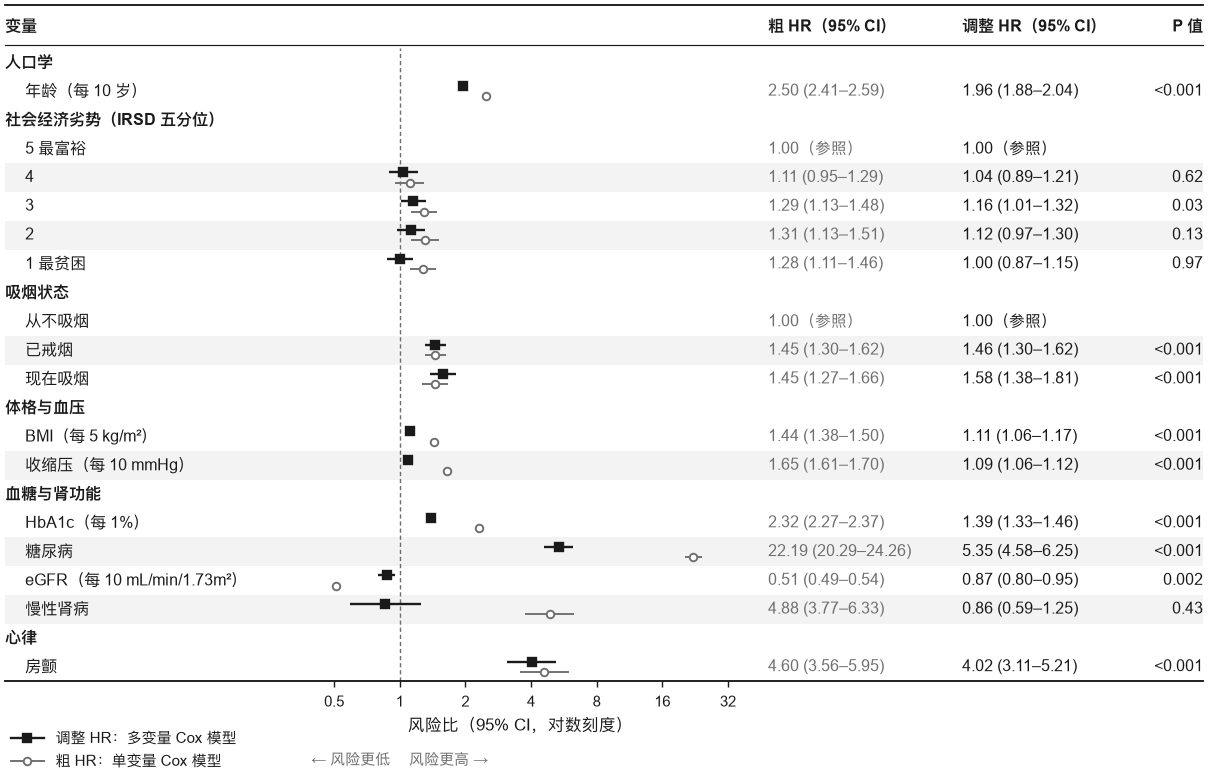

In [7]:
def fmt_ci(s, key):
    return f"{s.loc[key, 'exp(coef)']:.2f} ({s.loc[key, 'exp(coef) lower 95%']:.2f}–{s.loc[key, 'exp(coef) upper 95%']:.2f})"


def est_row(label, key):
    p = adjusted.loc[key, "p"]
    return {
        "label": label, "kind": "est",
        "hr": adjusted.loc[key, "exp(coef)"], "lo": adjusted.loc[key, "exp(coef) lower 95%"],
        "hi": adjusted.loc[key, "exp(coef) upper 95%"],
        "hr2": crude.loc[key, "exp(coef)"], "lo2": crude.loc[key, "exp(coef) lower 95%"],
        "hi2": crude.loc[key, "exp(coef) upper 95%"],
        "crude": fmt_ci(crude, key), "crude_color": pp.GREY, "adj": fmt_ci(adjusted, key),
        "p": "<0.001" if p < 0.001 else (f"{p:.3f}" if p < 0.01 else f"{p:.2f}"),
    }


def ref_row(label):
    return {"label": label, "kind": "ref", "crude": "1.00（参照）", "crude_color": pp.GREY,
            "adj": "1.00（参照）"}


def header(label):
    return {"label": label, "kind": "header"}


rows = [
    header("人口学"), est_row("年龄（每 10 岁）", "age_10"),
    header("社会经济劣势（IRSD 五分位）"), ref_row("5 最富裕"), est_row("4", "irsd_4"),
    est_row("3", "irsd_3"), est_row("2", "irsd_2"), est_row("1 最贫困", "irsd_1"),
    header("吸烟状态"), ref_row("从不吸烟"), est_row("已戒烟", "smoke_ex"),
    est_row("现在吸烟", "smoke_current"),
    header("体格与血压"), est_row("BMI（每 5 kg/m²）", "bmi_5"), est_row("收缩压（每 10 mmHg）", "sbp_10"),
    header("血糖与肾功能"), est_row("HbA1c（每 1%）", "hba1c"), est_row("糖尿病", "diabetes"),
    est_row("eGFR（每 10 mL/min/1.73m²）", "egfr_10"), est_row("慢性肾病", "CKD"),
    header("心律"), est_row("房颤", "AF"),
]
# 右侧文字列：(列标题, 行字典里的键, 该列距图左侧的毫米数, 对齐方式)
columns = [("粗 HR（95% CI）", "crude", 116, "left"), ("调整 HR（95% CI）", "adj", 145, "left"),
           ("P 值", "p", 181, "right")]

fig, ax = pp.forest_plot(rows, columns, xlim=(0.4, 32), ticks=[0.5, 1, 2, 4, 8, 16, 32],
                         label_mm=48, plot_mm=62, primary_label="调整 HR：多变量 Cox 模型",
                         secondary_label="粗 HR：单变量 Cox 模型")
pp.save(fig, "03_forest_plot")
plt.show()

🎨 **设计要点**（参考 Lancet / JAMA 的森林图版式）
- **"左表右图"**：变量名、图形、数值在同一行，视线横向一扫就能对上。隔行浅灰底纹帮助对齐
- **三线表**：只有顶线、表头下线和底线，没有竖线，这是期刊表格的通用规范
- **变量分组 + 参照组单独列出**：写明"1.00（参照）"，读者立刻知道每个 HR 是跟谁比
- **对数横轴**：保护作用（HR < 1）和危害作用（HR > 1）在视觉上对称
- **黑色实心方块 = 调整 HR（主要结果），灰色空心圆 = 粗 HR（参照信息）**：用"颜色深浅 + 实心/空心"区分主次，不依赖彩色，黑白打印也能分辨
- **读这张图**：BMI、收缩压、HbA1c 的方块比圆圈更靠近 1，说明它们的粗关联有一部分来自其他因素；慢性肾病从明显的风险因素（圆圈约 4.9）变成不显著（方块跨过 1）；IRSD 的圆圈都在 1 右侧，方块却回到了 1 附近（见 5.7 节）

> **图 8｜CVD 风险因素的风险比。** 粗 HR 来自只含单个变量的 Cox 模型；调整 HR 来自同时纳入表中全部变量的 Cox 模型。横线为 95% CI，横轴为对数刻度。P 值对应调整 HR。

### 5.6 解读：调整后发生了什么？

几个值得停下来想一想的地方：

**① 糖尿病的 HR 从 22 降到约 5.4。** 单变量模型里，糖尿病"吸收"了很多其他因素的作用（糖尿病患者更老、血压更高、HbA1c 更高）。调整这些变量后，剩下的才是糖尿病"独立"的关联。这就是**混杂调整**。

**② 慢性肾病（CKD）调整后不显著（HR ≈ 0.86，CI 跨过 1）。** 单独看 CKD 的风险明显更高，但模型里同时放了 eGFR，而 CKD 本来就是用 eGFR 等指标诊断的。两者提供的信息高度重叠（**共线性**），CKD 的"额外"信息所剩无几；再加上 CKD 只有 340 人，估计也不稳定。

**③ IRSD 调整后几乎没有关联（HR ≈ 1.0–1.16）。** 第 2 周 a 里明明看到了社会经济梯度，为什么消失了？看下一节。

### 5.7 预测 vs 因果：IRSD 的"总效应"去哪了？

按照 PRIME-CVD 的因果图（DAG），贫困通过**吸烟、BMI**，再经由糖尿病、血压等途径影响 CVD：

```
IRSD（贫困） ──► 吸烟 ──► 血压、CKD、房颤 ──► CVD
      └────────► BMI  ──► 糖尿病、血压     ──► CVD
```

多变量模型把这些**中介变量**全都调整掉了，所以 IRSD 的 HR 只剩下"不经过这些途径的直接作用"，接近 1。

如果研究问题是"**贫困人群的 CVD 风险总共高多少？**"（比如为了制定公共卫生政策），就**不应该**调整中介变量，只调整年龄这种混杂因素即可：

In [8]:
total = X[["age_10", "irsd_1", "irsd_2", "irsd_3", "irsd_4"]] \
    .assign(cvd_time=df["cvd_time"], cvd_event=df["cvd_event"])
cph_total = CoxPHFitter().fit(total, duration_col="cvd_time", event_col="cvd_event",
                              fit_options=FIT_OPTIONS)

irsd_rows = [LABELS[f"irsd_{q}"] for q in [1, 2, 3, 4]]
compare = pd.DataFrame({
    "只调整年龄（总效应）": hr_table(cph_total).loc[irsd_rows, "HR (95% CI)"],
    "调整全部变量（直接效应）": results.loc[irsd_rows, "HR (95% CI)"],
})
compare

,只调整年龄（总效应）,调整全部变量（直接效应）
IRSD 1 最贫困 vs 5,1.29 (1.12–1.48),1.00 (0.87–1.15)
IRSD 2 vs 5,1.27 (1.10–1.47),1.12 (0.97–1.30)
IRSD 3 vs 5,1.29 (1.13–1.48),1.16 (1.01–1.32)
IRSD 4 vs 5,1.07 (0.92–1.25),1.04 (0.89–1.21)


只调整年龄时，IRSD 1–3 组的风险都比最富裕组（5）高约 27–29%；把中介变量全部调整进来后，差异基本消失（IRSD 1 的 HR 变成 1.00）。

💡 **核心要点**：同一份数据，模型里放哪些变量取决于**你要回答什么问题**。
- **预测**（这个人 5 年内发病的概率是多少？）：放入所有有预测价值的变量
- **因果**（贫困对 CVD 的总影响有多大？）：根据因果图，调整混杂因素，**不调整中介变量**

这正是 PRIME-CVD 用已知因果图生成数据的教学价值：真实数据里我们永远不知道"正确答案"，这里知道。

### 5.8 检查比例风险（PH）假设

Cox 模型假设每个变量的 HR **不随时间变化**。常用的检验方法基于 Schoenfeld 残差：**P > 0.05 表示没有证据违反假设**。

In [9]:
ph = proportional_hazard_test(cph, model_data, time_transform="rank")
ph_table = ph.summary.loc[list(LABELS), ["test_statistic", "p"]].round(3)   # 按 LABELS 的顺序排列
ph_table.index = [LABELS[i] for i in ph_table.index]
ph_table

,test_statistic,p
年龄（每 10 岁）,0.452,0.501
BMI（每 5 kg/m²）,0.069,0.792
收缩压（每 10 mmHg）,0.358,0.550
eGFR（每 10 单位）,0.026,0.871
HbA1c（每 1%）,4.141,0.042
糖尿病,1.962,0.161
慢性肾病,0.264,0.607
房颤,0.160,0.689
已戒烟 vs 从不,1.363,0.243
现在吸烟 vs 从不,0.056,0.812


除了 HbA1c（P ≈ 0.04），其余变量的 P 值都 > 0.05。HbA1c 需要担心吗？

- 这里一共做了 14 个检验。即使假设全部成立，按 0.05 的标准，平均也会有 14 × 0.05 ≈ 0.7 个检验"碰巧"显著，这就是**多重检验**问题
- P = 0.04 只是勉强过线，而且这是模拟数据，生成时的 HR 本来就不随时间变化
- 实际工作中，遇到这种情况应该画出该变量的 Schoenfeld 残差图，看 HR 是否真的随时间有系统性变化。如果确实违反假设，可以用**分层 Cox 模型**，或者加入**变量 × 时间的交互项**

**结论**：没有强证据表明比例风险假设不成立。

### 5.9 模型好不好？C 指数（区分度）

**C 指数（concordance index）**：随机挑两个人，模型能正确判断"谁先发病"的概率。
- 0.5 = 和抛硬币一样
- 0.7 以上 = 可以接受
- 0.8 以上 = 很好

In [10]:
print(f"C 指数（在建模数据上评估）：{cph.concordance_index_:.3f}")

C 指数（在建模数据上评估）：0.876


0.876 看起来很高，但这是在**建模用的同一批数据**上算的，会偏乐观（就像用做过的题来考试）。更诚实的做法是把数据分成**训练集**和**测试集**：

In [11]:
rng = np.random.default_rng(2026)
is_train = rng.random(len(df)) < 0.7                  # 随机 70% 做训练，30% 做测试

cph_train = CoxPHFitter().fit(model_data[is_train], duration_col="cvd_time",
                              event_col="cvd_event", fit_options=FIT_OPTIONS)
test = model_data[~is_train]
risk_score = cph_train.predict_partial_hazard(test)   # 风险得分越高 = 越可能早发病
c_test = concordance_index(test["cvd_time"], -risk_score, test["cvd_event"])
print(f"训练集 C 指数：{cph_train.concordance_index_:.3f}")
print(f"测试集 C 指数：{c_test:.3f}")

训练集 C 指数：0.877
测试集 C 指数：0.873


测试集的 C 指数和训练集很接近，说明模型没有明显的**过拟合**：样本量大、变量少时通常就是这样。变量多、样本少的时候，两者的差距会大得多。

（C 指数只衡量"排序"对不对。预测的**绝对风险**准不准，要看**校准度（calibration）**，可以参考 PRIME-CVD 仓库里的 A004 系列教程。）

### 5.10 个体化预测：两位虚构的病人

Cox 模型可以给出某个人在 t 年内的发病概率：**5 年风险 = 1 − S(5)**。

⚠️ 这里用的是**合成数据**，结果只用来演示方法，**不能用于任何临床决策**。

In [12]:
patients = pd.DataFrame({
    "Age": [55, 65], "BMI": [24, 32], "SBP": [120, 150], "eGFR": [85, 70],
    "HbA1c": [5.0, 8.0], "diabetes": [0, 1], "CKD": [0, 0], "AF": [0, 0],
    "smoking_status": ["non", "current"], "IRSD_quintile": [5, 1],
}, index=["病人甲", "病人乙"])

surv5 = cph.predict_survival_function(make_design(patients), times=[5]).T
patients["5 年 CVD 风险"] = ((1 - surv5[5]) * 100).round(1).astype(str) + "%"
patients

,Age,BMI,SBP,eGFR,HbA1c,diabetes,CKD,AF,smoking_status,IRSD_quintile,5 年 CVD 风险
病人甲,55,24,120,85,5.0,0,0,0,non,5,1.4%
病人乙,65,32,150,70,8.0,1,0,0,current,1,69.2%


- **病人甲**：55 岁，不吸烟，血压、血糖正常，住在最富裕地区
- **病人乙**：65 岁，吸烟，有糖尿病（HbA1c 8%），高血压，住在最贫困地区

两人的 5 年风险相差几十倍。这就是心血管风险计算器（比如澳大利亚的 AusCVDRisk）背后的基本原理。

## 小结

| 方法 | 回答的问题 | lifelines 代码 |
|---|---|---|
| Cox 回归 | 调整其他因素后，各因素的 HR 是多少？ | `CoxPHFitter().fit(data, T, E)` |
| PH 假设检验 | HR 是否随时间变化？ | `proportional_hazard_test` |
| C 指数 | 模型能否区分高风险和低风险者？ | `concordance_index` |
| 个体预测 | 某个人 5 年内发病的概率？ | `predict_survival_function` |

**核心概念**：风险比、粗 HR 与调整 HR、混杂 vs 中介、预测 vs 因果、共线性、过拟合

## 练习

1. 在多变量模型里**去掉 HbA1c**，糖尿病的 HR 会怎么变？为什么？（提示：因果图里 糖尿病 → HbA1c）
2. 把吸烟状态的参照组改成"现在吸烟"，重新拟合。HR 的数值和含义有什么变化？
3. 修改 5.10 节病人乙的信息：如果他戒烟了（`"ex"`），5 年风险降低多少？如果收缩压降到 130 呢？
4. （进阶）把 `is_train` 的随机种子换成别的数字，测试集 C 指数变化大吗？这说明了什么？
5. （对照工程篇）w06b 用 statsmodels 在 70% 训练集上拟合。把它的 HR 表和本篇 5.4 节（lifelines、全部数据）对比，差异来自哪里？